# Recitation 1 demo: the running proportion of heads

Flip a fair coin many times and watch the proportion of heads settle down. This is the
law of large numbers, and it is also the whole skill behind the programming problems in
this course: draw a lot of random numbers, compute something from them, and plot it.

Run everything with **Runtime > Run all**, then change the numbers and run it again.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)     # fixed seed: the same flips every time
n = 1000                           # <- change me
print("ready")

ready


## One thousand flips

proportion of heads after 1000 flips: 0.4730


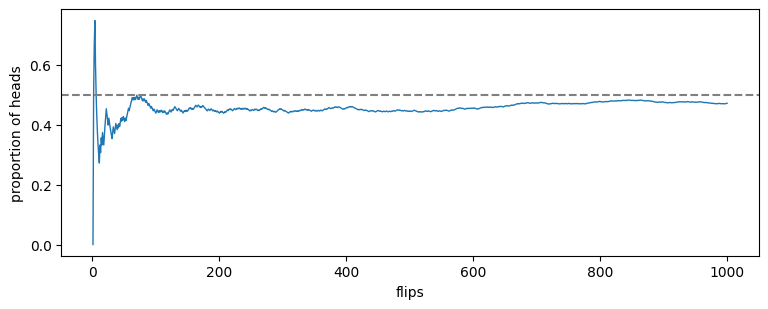

In [2]:
x = (rng.random(n) < 0.5).astype(float)      # 1 = heads
p = np.cumsum(x) / np.arange(1, n + 1)       # proportion of heads after each flip

print(f"proportion of heads after {n} flips: {p[-1]:.4f}")

plt.figure(figsize=(9, 3.2))
plt.plot(np.arange(1, n + 1), p, linewidth=1)
plt.axhline(0.5, color="gray", linestyle="--")
plt.xlabel("flips")
plt.ylabel("proportion of heads")
plt.show()

Wild at the start, then it settles toward one half. Note that it does not *reach* one
half and stay there: it keeps wobbling, and the wobbles get smaller.

## How big are the wobbles?

Five repetitions of the same experiment, drawn on top of each other, with the band
$0.5 \pm 2\sqrt{0.25/n}$ (two standard errors) in grey.

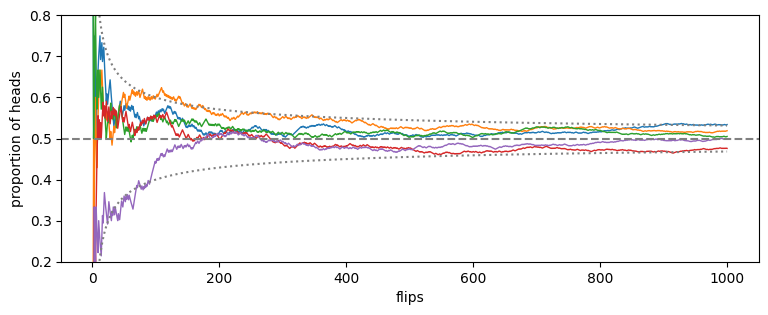

In [3]:
flips = np.arange(1, n + 1)
band = 2 * np.sqrt(0.25 / flips)

plt.figure(figsize=(9, 3.2))
for _ in range(5):
    x = (rng.random(n) < 0.5).astype(float)
    plt.plot(flips, np.cumsum(x) / flips, linewidth=1)
plt.plot(flips, 0.5 + band, color="gray", linestyle=":")
plt.plot(flips, 0.5 - band, color="gray", linestyle=":")
plt.axhline(0.5, color="gray", linestyle="--")
plt.ylim(0.2, 0.8)
plt.xlabel("flips")
plt.ylabel("proportion of heads")
plt.show()

Every run is different, but they all get squeezed toward one half at the same rate: the
band narrows like $1/\sqrt{n}$. That rate is the central limit theorem showing up early.

## The rate, in numbers

In [4]:
for n_ in [100, 1000, 10000, 1000000]:
    se = np.sqrt(0.25 / n_)
    print(f"n = {n_:>7d}:  standard error {se:.4f}   "
          f"so about 95% of runs end between {0.5 - 2*se:.3f} and {0.5 + 2*se:.3f}")

n =     100:  standard error 0.0500   so about 95% of runs end between 0.400 and 0.600
n =    1000:  standard error 0.0158   so about 95% of runs end between 0.468 and 0.532
n =   10000:  standard error 0.0050   so about 95% of runs end between 0.490 and 0.510
n = 1000000:  standard error 0.0005   so about 95% of runs end between 0.499 and 0.501


To halve the wobble you need four times as many flips. That is why a poll of 1000 people
has a margin of error of about 3 percentage points, and why getting to 0.3 points would
need about 100000 people.

---

The same simulation is in this folder as a script in MATLAB, Python, R and Julia
(`running_proportion.*`). This notebook is part of STAN, the code repository for
MATH 166 at Tufts University: <https://github.com/andreasmang/stan>.